# Finding networks in a complex system

A community (also called a cluster or module) is a group of nodes in a graph that are more densely connected to each other than to the rest of the network.

In [30]:
def readNetwork(filename):
	with open(filename, 'r') as file:
		net = { 'noNodes' : int(file.readline()) }

		matrix: list = []
		degree: list = []
		noEdges = 0

		for _ in range(net['noNodes']):
			matrix.append([])
			for node in file.readline().split():
				matrix[-1].append(int(node))
			degree.append(sum(matrix[-1]))
			noEdges += degree[-1]

		net['matrix'] = matrix
		net['degree'] = degree
		net['noEdges'] = noEdges

		return net

In [31]:
network = readNetwork('data/graph.in')

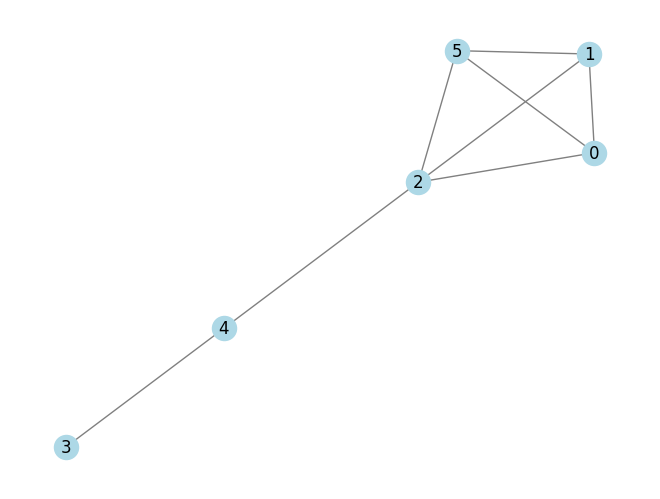

In [32]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

A = np.array(network['matrix'])
G = nx.from_numpy_array(A)
nx.draw(G, with_labels=True, node_color='lightblue', edge_color='gray')
plt.show()

**Greedy Modularity** it works by iteratively merging communities that result in the largest increase in modularity until no further improvement can be made. Modularity is a measure of the strength of division of a network into communities, with higher values indicating stronger community structure. The algorithm starts with each node as its own community and merges them based on the modularity gain until it reaches a local maximum.

In [33]:
from networkx.algorithms import community

communities = community.greedy_modularity_communities(G)

n = network['noNodes']
partition = [0] * n
for community_id, nodes in enumerate(communities):
	for node in nodes:
		partition[node] = community_id

print(partition)

[0, 0, 0, 1, 1, 0]


In [34]:
def modularity(G, partition):
	pos = nx.spring_layout(G)
	plt.figure(figsize=(8, 6))
	nx.draw_networkx_nodes(G, pos, node_color=partition, cmap=plt.cm.Set3, node_size=300)
	nx.draw_networkx_edges(G, pos, edge_color='gray')
	plt.title('Community Detection using Greedy Modularity')
	plt.axis('off')
	plt.show()

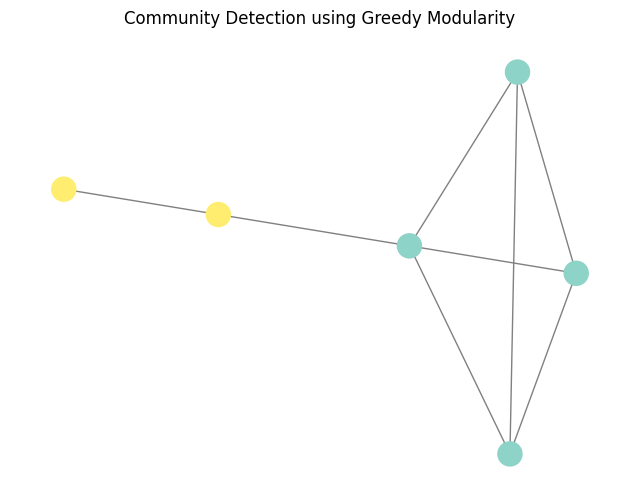

In [35]:
modularity(G, partition)

## Community with Genetic Algorithm

Genetic algorithms are optimization techniques inspired by the process of natural selection. 

Now to do this we must first understand what we work with. We have a chromosome, we want to transform with chromosome into communities. Every index is a node, and the value of the chromosome[index] is the community that the node belongs to.

For the fetness function we will use modularity, from `networkx` library. What does this function do? It measures the strength of division of a network into communities. A higher modularity value indicates a stronger community structure, meaning that there are more edges within communities than between them.

In [36]:
from networkx.algorithms import community as nx_community

def chromosomeToCommunities(chromosome, nodes):
    communities = {}
    for idx, comm_id in enumerate(chromosome):
        communities.setdefault(comm_id, set()).add(nodes[idx])
    return list(communities.values())


def fitness(chromosome, G, nodes):
    """Modularity Q — higher is better."""
    communities = chromosomeToCommunities(chromosome, nodes)
    if len(communities) == 1:
        return 0.0
    return nx_community.modularity(G, communities)

Now that we know what we work with, we can start the second part: population. Every chromosome is just a vector of size n with random values between 0 and n (the number of nodes).

In [37]:
import random 

def randomChromosome(n_nodes, n_communities):
    return [random.randint(0, n_communities - 1) for _ in range(n_nodes)]


def initPopulation(pop_size, n_nodes, n_communities):
    return [randomChromosome(n_nodes, n_communities) for _ in range(pop_size)]

For reproduction we will want to mate the best chromosomes. We need a `tornament selection` to select the best chromosomes. We don't want have the entire population the the tornament, we want to have a random sample because we want to have some diversity in the population. If we would use the entire population, we would have a very low diversity and we would get stuck in a local maximum.

In [38]:
def tournamentSelection(population, fitnesses, tournament_size):
    contestants_idx = random.sample(range(len(population)), tournament_size)
    best_idx = max(contestants_idx, key=lambda i: fitnesses[i])
    return population[best_idx]

For mateing we will use `one point crossover`. We will select a random point in the chromosome and we will swap the values of the two parents after that point. This way we will create two children that are a combination of the two parents.

In [39]:
def singlePointCrossover(parent1, parent2):
    n = len(parent1)
    cut = random.randint(1, n - 1)  # at least 1 gene from each parent
    child = parent1[:cut] + parent2[cut:]
    return child

We want to have some m-mrrr-mmmrr-mutation to find better solutions. We wan't our children like this!
![Mutation Example](data/cat.png)

In [40]:
def mutate(chromosome, mutation_rate, n_communities):
    mutated = chromosome[:]
    for i in range(len(mutated)):
        if random.random() < mutation_rate:
            mutated[i] = random.randint(0, n_communities - 1)
    return mutated

In [41]:
def geneticAlgorithm(G, n_communities, pop_size=100, generations=200, mutation_rate=0.05, tournament_size=5):
    
    n_nodes = G.number_of_nodes()
    nodes = list(G.nodes())

    population = initPopulation(pop_size, n_nodes, n_communities)
    fitnesses = [fitness(ch, G, nodes) for ch in population]

    best_chromosome = max(population, key=lambda ch: fitness(ch, G, nodes))
    best_fitness = fitness(best_chromosome, G, nodes)

    print(f"Gen 0 — best modularity: {best_fitness:.4f}")

    for gen in range(1, generations + 1):
        new_population = []

        for _ in range(pop_size):
            parent1 = tournamentSelection(population, fitnesses, tournament_size)
            parent2 = tournamentSelection(population, fitnesses, tournament_size)
            child = singlePointCrossover(parent1, parent2)
            child = mutate(child, mutation_rate, n_communities)
            new_population.append(child)

        population = new_population
        fitnesses = [fitness(ch, G, nodes) for ch in population]

        gen_best = max(population, key=lambda ch: fitness(ch, G, nodes))
        gen_best_fit = fitness(gen_best, G, nodes)

        if gen_best_fit > best_fitness:
            best_fitness = gen_best_fit
            best_chromosome = gen_best[:]

        if gen % 20 == 0:
            print(f"Gen {gen} — best modularity: {best_fitness:.4f}")

    print(f"\nFinal best modularity: {best_fitness:.4f}")
    print(f"Communities found: {len(set(best_chromosome))}")
    return best_chromosome, best_fitness, nodes

In [42]:
A = np.array(network['matrix'])
G = nx.from_numpy_array(A)

best_partition, _, _ = geneticAlgorithm(
    G,
    n_communities = 4,
    pop_size = 100,
    generations = 200,
    mutation_rate = 0.05,
    tournament_size = 5
)

print("\nPartition:", best_partition)

Gen 0 — best modularity: 0.0703
Gen 20 — best modularity: 0.1797
Gen 40 — best modularity: 0.1797
Gen 60 — best modularity: 0.1797
Gen 80 — best modularity: 0.1797
Gen 100 — best modularity: 0.1797
Gen 120 — best modularity: 0.1797
Gen 140 — best modularity: 0.1797
Gen 160 — best modularity: 0.1797
Gen 180 — best modularity: 0.1797
Gen 200 — best modularity: 0.1797

Final best modularity: 0.1797
Communities found: 2

Partition: [3, 3, 3, 2, 2, 3]


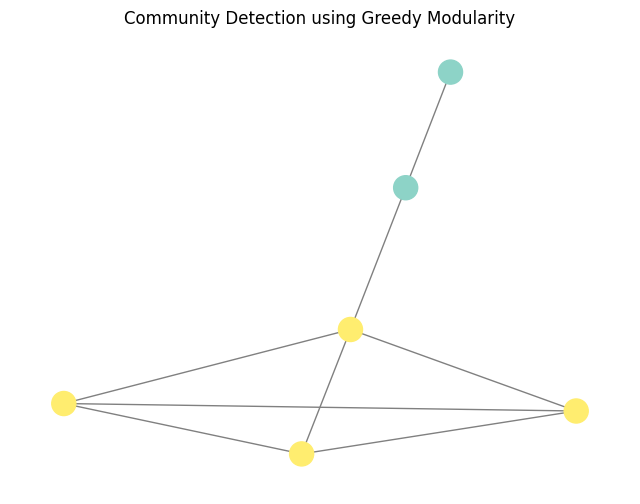

In [43]:
modularity(G, best_partition)

Gen 0 — best modularity: 0.0433
Gen 20 — best modularity: 0.2968
Gen 40 — best modularity: 0.3776
Gen 60 — best modularity: 0.4201
Gen 80 — best modularity: 0.4320
Gen 100 — best modularity: 0.4368
Gen 120 — best modularity: 0.4368
Gen 140 — best modularity: 0.4390
Gen 160 — best modularity: 0.4425
Gen 180 — best modularity: 0.4521
Gen 200 — best modularity: 0.4521

Final best modularity: 0.4521
Communities found: 4
Beak -> community 0; Beescratch -> community 3; Bumper -> community 0; CCL -> community 3; Cross -> community 2; DN16 -> community 1; DN21 -> community 1; DN63 -> community 3; Double -> community 3; Feather -> community 1; Fish -> community 0; Five -> community 2; Fork -> community 0; Gallatin -> community 1; Grin -> community 2; Haecksel -> community 2; Hook -> community 2; Jet -> community 1; Jonah -> community 2; Knit -> community 3; Kringel -> community 0; MN105 -> community 2; MN23 -> community 1; MN60 -> community 2; MN83 -> community 2; Mus -> community 3; Notch -> c

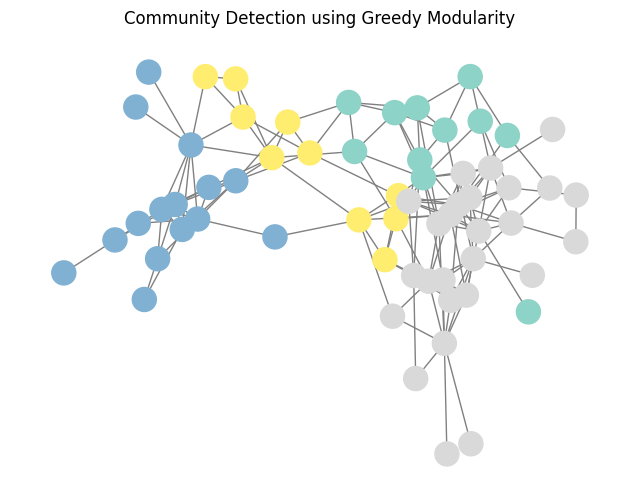

In [44]:
G = nx.read_gml('data/real-networks/real/dolphins/dolphins.gml')

best_partition, best_Q, nodes = geneticAlgorithm(
    G,
    n_communities  = 4,
    pop_size       = 100,
    generations    = 200,
    mutation_rate  = 0.05,
    tournament_size= 5
)

for i, node in enumerate(nodes):
    print(f"{node} -> community {best_partition[i]}", end='; ')
    
modularity(G, best_partition)

Whos fotball data is this???
```python
NetworkXError: edge #51 (27--17) is duplicated
```

In [45]:
def read_gml_safe(path):
    with open(path, 'r') as f:
        lines = f.readlines()

    edges_seen = set()
    in_edge    = False
    source     = None
    target     = None

    for line in lines:
        stripped = line.strip()

        if stripped == 'edge':          
            in_edge        = True
            source, target = None, None

        elif in_edge:
            if stripped == '[':         
                continue
            elif stripped.startswith('source'):
                source = int(stripped.split()[1])
            elif stripped.startswith('target'):
                target = int(stripped.split()[1])
            elif stripped == ']':
                in_edge = False
                if source is not None and target is not None:
                    edge_key = (min(source, target), max(source, target))
                    edges_seen.add(edge_key)

    G = nx.Graph()
    G.add_edges_from(edges_seen)

    return G

Gen 0 — best modularity: 0.0345
Gen 20 — best modularity: 0.1748
Gen 40 — best modularity: 0.2668
Gen 60 — best modularity: 0.3009
Gen 80 — best modularity: 0.3337
Gen 100 — best modularity: 0.3387
Gen 120 — best modularity: 0.3393
Gen 140 — best modularity: 0.3416
Gen 160 — best modularity: 0.3416
Gen 180 — best modularity: 0.3416
Gen 200 — best modularity: 0.3553

Final best modularity: 0.3553
Communities found: 4


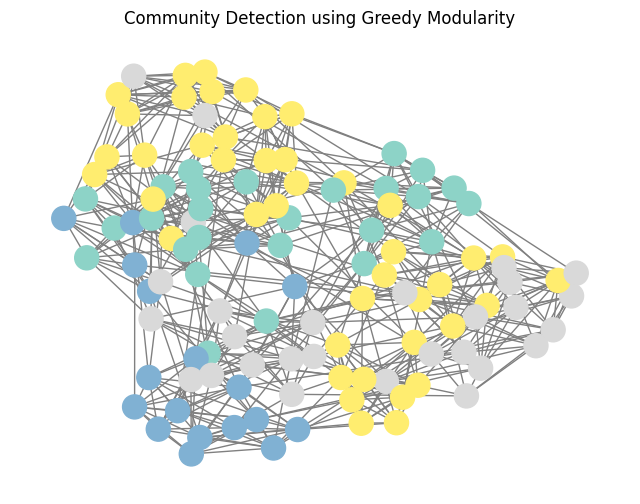

In [46]:
G = read_gml_safe('data/real-networks/real/football/football.gml')

best_partition, best_Q, nodes = geneticAlgorithm(
    G,
    n_communities  = 4,
    pop_size       = 100,
    generations    = 200,
    mutation_rate  = 0.05,
    tournament_size= 5
)
    
modularity(G, best_partition)

Gen 0 — best modularity: 0.1056
Gen 20 — best modularity: 0.3633
Gen 40 — best modularity: 0.3707
Gen 60 — best modularity: 0.3860
Gen 80 — best modularity: 0.3872
Gen 100 — best modularity: 0.3924
Gen 120 — best modularity: 0.3959
Gen 140 — best modularity: 0.3959
Gen 160 — best modularity: 0.3959
Gen 180 — best modularity: 0.3959
Gen 200 — best modularity: 0.3959

Final best modularity: 0.3959
Communities found: 3


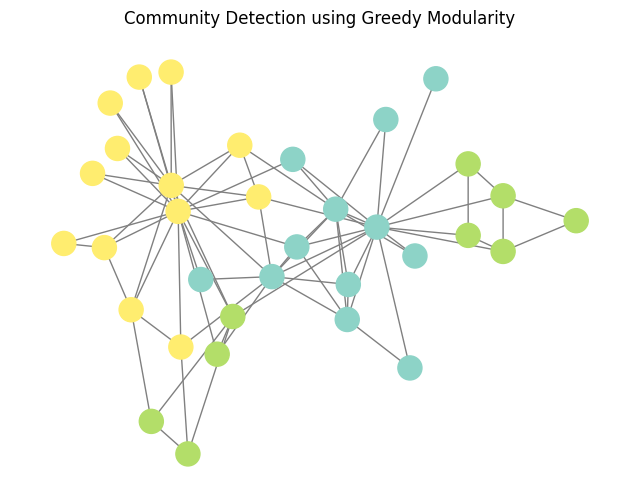

In [49]:
G = nx.read_gml('data/real-networks/real/karate/karate.gml', label='id')

best_partition, best_Q, nodes = geneticAlgorithm(
    G,
    n_communities  = 4,
    pop_size       = 100,
    generations    = 200,
    mutation_rate  = 0.05,
    tournament_size= 5
)
    
modularity(G, best_partition)

Gen 0 — best modularity: 0.0402
Gen 20 — best modularity: 0.2244
Gen 40 — best modularity: 0.3317
Gen 60 — best modularity: 0.3687
Gen 80 — best modularity: 0.4027
Gen 100 — best modularity: 0.4110
Gen 120 — best modularity: 0.4110
Gen 140 — best modularity: 0.4264
Gen 160 — best modularity: 0.4264
Gen 180 — best modularity: 0.4264
Gen 200 — best modularity: 0.4264

Final best modularity: 0.4264
Communities found: 4


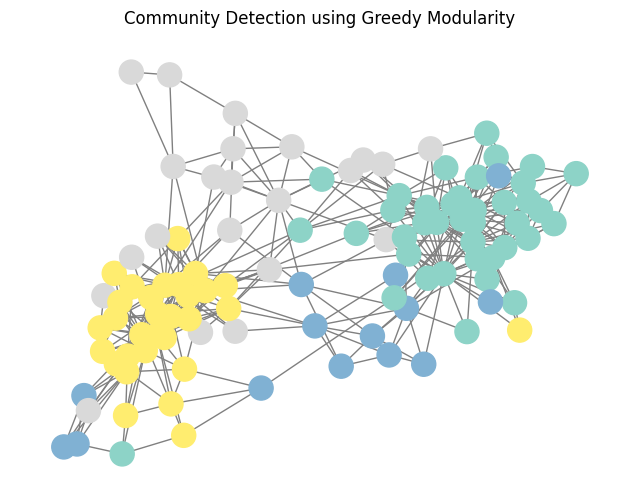

In [50]:
G = nx.read_gml('data/real-networks/real/krebs/krebs.gml')

best_partition, best_Q, nodes = geneticAlgorithm(
    G,
    n_communities  = 4,
    pop_size       = 100,
    generations    = 200,
    mutation_rate  = 0.05,
    tournament_size= 5
)
    
modularity(G, best_partition)

For the communities that we have to find I will just use the ones form `networkx` library. It is a cheachy way to complete the assigment? yes.

> [doc](https://networkx.org/documentation/stable/reference/generated/networkx.generators.intersection.uniform_random_intersection_graph.html)

Gen 0 — best modularity: 0.1073
Gen 20 — best modularity: 0.4307
Gen 40 — best modularity: 0.4836
Gen 60 — best modularity: 0.5000
Gen 80 — best modularity: 0.5047
Gen 100 — best modularity: 0.5047
Gen 120 — best modularity: 0.5047
Gen 140 — best modularity: 0.5047
Gen 160 — best modularity: 0.5053
Gen 180 — best modularity: 0.5053
Gen 200 — best modularity: 0.5061

Final best modularity: 0.5061
Communities found: 4


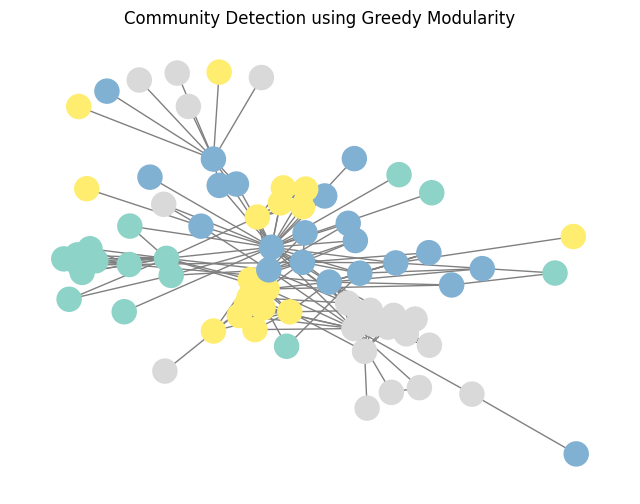

In [51]:
G = nx.les_miserables_graph()

best_partition, best_Q, nodes = geneticAlgorithm(
    G,
    n_communities  = 4,
    pop_size       = 100,
    generations    = 200,
    mutation_rate  = 0.05,
    tournament_size= 5
)
    
modularity(G, best_partition)

Gen 0 — best modularity: 0.0518
Gen 20 — best modularity: 0.2558
Gen 40 — best modularity: 0.2730
Gen 60 — best modularity: 0.2750
Gen 80 — best modularity: 0.2750
Gen 100 — best modularity: 0.2750
Gen 120 — best modularity: 0.2750
Gen 140 — best modularity: 0.2750
Gen 160 — best modularity: 0.2757
Gen 180 — best modularity: 0.2757
Gen 200 — best modularity: 0.2757

Final best modularity: 0.2757
Communities found: 4


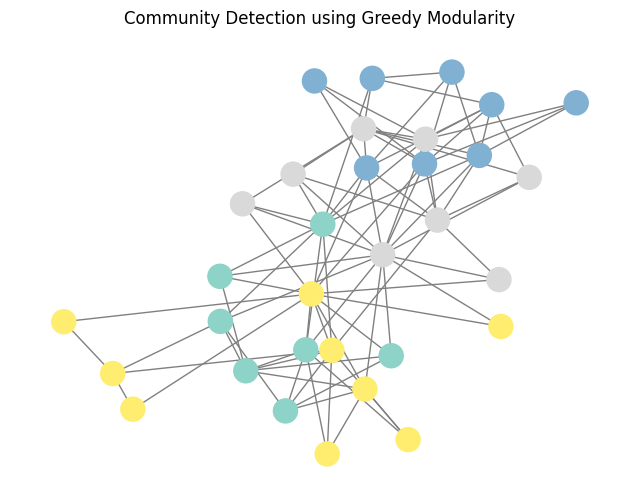

In [52]:
G = nx.davis_southern_women_graph()

best_partition, best_Q, nodes = geneticAlgorithm(
    G,
    n_communities  = 4,
    pop_size       = 100,
    generations    = 200,
    mutation_rate  = 0.05,
    tournament_size= 5
)
    
modularity(G, best_partition)

Gen 0 — best modularity: 0.1513
Gen 20 — best modularity: 0.3987
Gen 40 — best modularity: 0.3987
Gen 60 — best modularity: 0.3987
Gen 80 — best modularity: 0.3987
Gen 100 — best modularity: 0.3987
Gen 120 — best modularity: 0.3987
Gen 140 — best modularity: 0.3987
Gen 160 — best modularity: 0.3987
Gen 180 — best modularity: 0.3987
Gen 200 — best modularity: 0.3987

Final best modularity: 0.3987
Communities found: 3


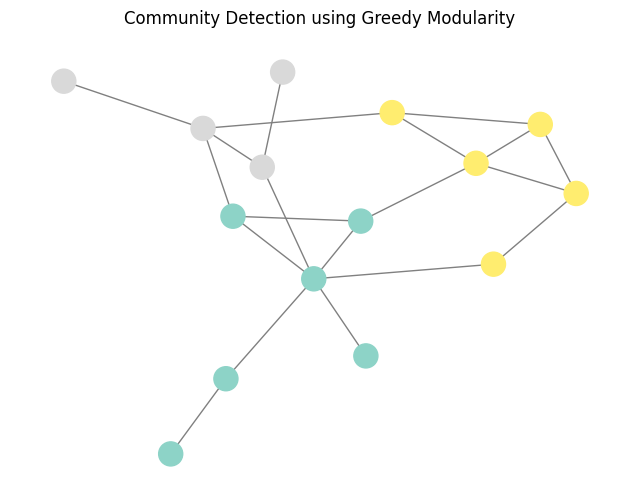

In [53]:
G = nx.florentine_families_graph()

best_partition, best_Q, nodes = geneticAlgorithm(
    G,
    n_communities  = 4,
    pop_size       = 100,
    generations    = 200,
    mutation_rate  = 0.05,
    tournament_size= 5
)
    
modularity(G, best_partition)

Gen 0 — best modularity: 0.0562
Gen 20 — best modularity: 0.3963
Gen 40 — best modularity: 0.4321
Gen 60 — best modularity: 0.4345
Gen 80 — best modularity: 0.4345
Gen 100 — best modularity: 0.4345
Gen 120 — best modularity: 0.4345
Gen 140 — best modularity: 0.4345
Gen 160 — best modularity: 0.4345
Gen 180 — best modularity: 0.4345
Gen 200 — best modularity: 0.4345

Final best modularity: 0.4345
Communities found: 3


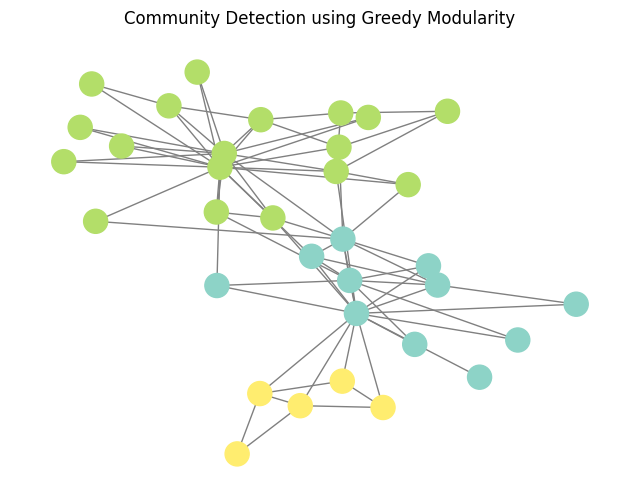

In [54]:
G = nx.karate_club_graph()

best_partition, best_Q, nodes = geneticAlgorithm(
    G,
    n_communities  = 4,
    pop_size       = 100,
    generations    = 200,
    mutation_rate  = 0.05,
    tournament_size= 5
)
    
modularity(G, best_partition)

Gen 0 — best modularity: 0.0183
Gen 20 — best modularity: 0.1329
Gen 40 — best modularity: 0.2190
Gen 60 — best modularity: 0.2612
Gen 80 — best modularity: 0.2821
Gen 100 — best modularity: 0.2831
Gen 120 — best modularity: 0.2866
Gen 140 — best modularity: 0.2924
Gen 160 — best modularity: 0.2926
Gen 180 — best modularity: 0.2933
Gen 200 — best modularity: 0.2933

Final best modularity: 0.2933
Communities found: 4


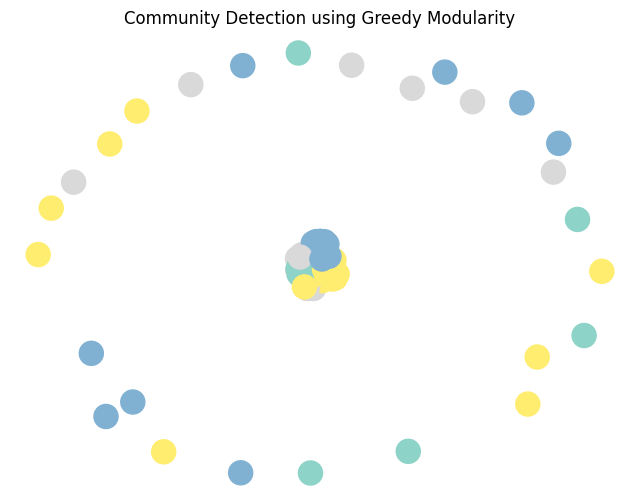

In [55]:
G = nx.uniform_random_intersection_graph(100, 10, 0.1)

best_partition, best_Q, nodes = geneticAlgorithm(
    G,
    n_communities  = 4,
    pop_size       = 100,
    generations    = 200,
    mutation_rate  = 0.05,
    tournament_size= 5
)
    
modularity(G, best_partition)